# Estadística descriptiva: resumir una variable con pocos números

> Cómo describir una variable numérica con una medida de centro (media, mediana), una de dispersión (varianza, desviación típica, rango intercuartílico) y una de forma (asimetría, curtosis); cuándo cada una engaña, qué es la corrección de Bessel y para qué sirve estandarizar.
>
> **Relacionado:** [Análisis exploratorio](../03-preparacion-datos/01-analisis-exploratorio.ipynb) · [Transformación de datos](../03-preparacion-datos/03-transformacion-datos.ipynb) · [Distribuciones de probabilidad](02-distribuciones-probabilidad.ipynb)

## 1. Idea clave

Antes de modelar hay que saber **cómo es** cada variable. La estadística descriptiva la resume con pocos números que responden a tres preguntas: **¿dónde está?** (centro: media, mediana), **¿cuánto se dispersa?** (dispersión: desviación típica, rango intercuartílico) y **¿qué forma tiene?** (asimetría, curtosis, colas). Esos números **no son intercambiables**: la media y la desviación típica se dejan arrastrar por unos pocos valores extremos; la mediana y el rango intercuartílico no.

Saber cuál usar y cuándo desconfiar de ellos evita errores frecuentes: dar un "valor típico" que no es típico de nadie, dividir por $n$ en vez de $n-1$ al estimar la varianza, o creer que dos variables con los mismos resúmenes son iguales. Este notebook es la base del [análisis exploratorio](../03-preparacion-datos/01-analisis-exploratorio.ipynb) y de la inferencia que viene después.

## 2. Conceptos importantes

### 2.1. Población y muestra

La **población** es el conjunto completo de individuos de interés y una **muestra**, un subconjunto de ella. Una cantidad que describe la población se llama **parámetro** ($\mu$ para la media, $\sigma^2$ para la varianza) y una calculada con la muestra, **estadístico** ($\bar{x}$, $s^2$). Casi nunca conocemos los parámetros: los **estimamos** con los estadísticos, y de ahí sale la diferencia de fórmulas que veremos en 2.3.

### 2.2. Medidas de centro

Dados $n$ valores $x_1,\dots,x_n$ y sus valores ordenados $x_{(1)}\le\dots\le x_{(n)}$:

- **Moda**: el valor más frecuente. Es la única medida de centro útil con variables categóricas; con numéricas continuas apenas tiene sentido (casi nada se repite).
- **Mediana**: el valor que deja la mitad de los datos a cada lado. Es $x_{((n+1)/2)}$ si $n$ es impar y la media de los dos valores centrales si es par.
- **Media aritmética**: $\bar{x}=\dfrac{1}{n}\sum_{i=1}^{n}x_i$.
- **Media recortada** (*trimmed mean*): la media tras descartar el $p\,\%$ de valores más bajos y más altos; es un punto intermedio entre ambas.

Propiedades que explican su comportamiento:

- La media es el valor $c$ que minimiza $\sum_i (x_i-c)^2$ (el punto de equilibrio del histograma) y la mediana, el que minimiza $\sum_i |x_i-c|$.
- **Robustez**: cambiar un solo valor por uno enorme mueve la media tanto como se quiera; la mediana apenas se mueve (hace falta alterar la mitad de los datos para estropearla).
- **Transformaciones lineales**: si $y_i=a x_i+b$, entonces $\bar{y}=a\bar{x}+b$ y la mediana se transforma igual (un cambio de unidades, p. ej. de miles a unidades, es una transformación lineal).
- **Media y mediana juntas** informan de la forma: en una distribución simétrica coinciden; con cola a la derecha, la media queda por encima de la mediana (los extremos la arrastran), y al revés si la cola es a la izquierda.

### 2.3. Medidas de dispersión

- **Rango**: $x_{(n)}-x_{(1)}$. Depende solo de los dos extremos, así que es muy inestable.
- **Cuartiles** $Q_1,Q_2,Q_3$: dejan por debajo el 25 %, 50 % (la mediana) y 75 % de los datos. El **rango intercuartílico** (RIC o IQR) es $Q_3-Q_1$: la anchura del 50 % central. El **resumen de cinco números** es (mínimo, $Q_1$, mediana, $Q_3$, máximo) y se dibuja con un **diagrama de caja** (*boxplot*), cuyos bigotes llegan hasta el dato más lejano dentro de $[Q_1-1{,}5\,\mathrm{RIC},\,Q_3+1{,}5\,\mathrm{RIC}]$ (los puntos fuera se marcan como posibles atípicos).
- **Varianza** y **desviación típica**. Con los datos de una muestra:

$$
s^2=\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2,\qquad s=\sqrt{s^2},
$$

mientras que si los datos son **toda la población**, $\sigma^2=\frac{1}{N}\sum_{i=1}^{N}(x_i-\mu)^2$. La **corrección de Bessel** ($n-1$ en vez de $n$) compensa que las desviaciones se miden respecto a $\bar{x}$, que está "pegada" a los datos: $\sum_i(x_i-\bar{x})^2$ es **menor** que $\sum_i(x_i-\mu)^2$, así que dividir por $n$ **subestima** $\sigma^2$ de media. Dividiendo por $n-1$ (los **grados de libertad**: las $n$ desviaciones respecto a $\bar{x}$ suman 0, así que solo $n-1$ son libres) se cumple $\mathbb{E}[s^2]=\sigma^2$ (estimador insesgado). La desviación típica, en cambio, sigue subestimando $\sigma$ un poco.

- **Desviación absoluta mediana** (MAD): $\mathrm{MAD}=\mathrm{mediana}\,|x_i-\mathrm{mediana}(x)|$. Es la alternativa robusta a la desviación típica; multiplicada por $1{,}4826$ equivale a $\sigma$ si los datos son normales.
- **Coeficiente de variación**: $\mathrm{CV}=s/\bar{x}$ (adimensional; solo para variables positivas con ceros reales), sirve para comparar la dispersión de variables en escalas distintas.
- Propiedades: si $y=ax+b$, entonces $s_y=|a|\,s_x$ (sumar una constante no cambia la dispersión).

**Regla de Chebyshev.** Para **cualquier** distribución, al menos una fracción $1-1/k^2$ de los datos está a menos de $k$ desviaciones típicas de la media (en $k=2$, el 75 %; en $k=3$, el 88,9 %). Es una cota general y, por eso, conservadora. Si los datos son aproximadamente normales, la **regla empírica** dice que ≈ 68 %, 95 % y 99,7 % están a menos de 1, 2 y 3 desviaciones.

### 2.4. Forma: asimetría y curtosis

Con los momentos centrales $m_k=\frac1n\sum_i(x_i-\bar{x})^k$:

- **Asimetría** (*skewness*): $g_1=m_3/m_2^{3/2}$. Vale $0$ si es simétrica, es **positiva** con cola larga a la derecha (ingresos, precios) y **negativa** con cola a la izquierda.
- **Curtosis** (*kurtosis*): $g_2=m_4/m_2^{2}-3$ (la **curtosis en exceso**: la normal vale 0). Valores altos indican **colas pesadas** (más valores extremos de los que daría una normal).

Los dos coeficientes elevan las desviaciones a la 3.ª y 4.ª potencia, así que están dominados por los valores extremos y son muy inestables con pocos datos. Una variable muy asimétrica positiva se suele aproximar a la simetría con una transformación como el logaritmo ([transformación de datos](../03-preparacion-datos/03-transformacion-datos.ipynb)).

### 2.5. Estandarización

La **puntuación z** expresa cada valor en desviaciones típicas respecto a la media:

$$
z_i=\frac{x_i-\bar{x}}{s}.
$$

Los datos estandarizados tienen media 0 y desviación típica 1 y permiten **comparar variables de escalas distintas** o ver cuánto se aleja un dato de lo habitual. Cuando hay atípicos, la versión robusta usa la mediana y el MAD: $z^{*}_i=(x_i-\mathrm{mediana})/(1{,}4826\,\mathrm{MAD})$. El uso de $z$ como "probabilidad de ser raro" supone que los datos son aproximadamente normales.

## 3. Código

Usamos **California housing** (20 640 distritos censales de California, censo de 1990; `fetch_california_housing`) y cuatro de sus variables: `MedInc` (ingreso mediano del distrito, en decenas de miles de dólares), `HouseAge` (antigüedad mediana de las viviendas, en años), `Population` (habitantes del distrito) y `AveRooms` (habitaciones medias por vivienda). Tienen formas muy distintas: `HouseAge` es casi simétrica y `Population` y `AveRooms` tienen colas muy largas. Es la versión de scikit-learn, ya preparada: no tiene valores ausentes, y la antigüedad `HouseAge` está **recortada en 52** años (los distritos con viviendas más antiguas figuran con 52).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing

### 3.1. Datos y resumen rápido

In [2]:
datos = fetch_california_housing(as_frame=True).frame[["MedInc", "HouseAge", "Population", "AveRooms"]]
print(datos.shape)
datos.describe().round(2).T

(20640, 4)


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00
HouseAge,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00
Population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
AveRooms,20640.0,5.43,2.47,0.85,4.44,5.23,6.05,141.91


`describe` da, de una vez, el número de datos, la media, la desviación típica y el resumen de cinco números. Ya se ven diferencias: en `Population` la media (1425) es bastante mayor que la mediana (1166) y el máximo (35 682) está lejísimos del tercer cuartil (1725); en `HouseAge` la media (28,6) y la mediana (29) casi coinciden. A partir de aquí vemos cada familia de medidas.

### 3.2. Centro: media, mediana y media recortada

Calculamos las tres para las cuatro variables y comprobamos a mano la media y la mediana de un ejemplo pequeño.

In [3]:
centro = pd.DataFrame({
    "media": datos.mean(),
    "mediana": datos.median(),
    "media recortada (10 %)": datos.apply(lambda s: stats.trim_mean(s, 0.1)),
})
centro["media - mediana"] = centro["media"] - centro["mediana"]
print(centro.round(2).to_string())
print(f"\nHouseAge: moda = {datos['HouseAge'].mode().iloc[0]:.0f} años ({(datos['HouseAge'] == 52).mean():.1%} de los distritos tienen exactamente 52, el valor recortado)")

# Comprobación a mano con 9 valores (p. ej. salarios mensuales en miles de euros)
x = np.array([1.8, 2.0, 2.1, 2.3, 2.4, 2.6, 2.7, 3.0, 3.1])
media_a_mano = x.sum() / len(x)
mediana_a_mano = np.sort(x)[len(x) // 2]          # n impar: el valor central
print(f"\nA mano: media {media_a_mano:.3f} (numpy {x.mean():.3f}), mediana {mediana_a_mano} (numpy {np.median(x)})")

              media  mediana  media recortada (10 %)  media - mediana
MedInc         3.87     3.53                    3.65             0.34
HouseAge      28.64    29.00                   28.49            -0.36
Population  1425.48  1166.00                 1256.51           259.48
AveRooms       5.43     5.23                    5.25             0.20

HouseAge: moda = 52 años (6.2% de los distritos tienen exactamente 52, el valor recortado)

A mano: media 2.444 (numpy 2.444), mediana 2.4 (numpy 2.4)


En `Population` la media está **260 por encima** de la mediana y la media recortada (1256) queda entre las dos; en `HouseAge` (casi simétrica) las tres coinciden. `AveRooms` tiene la media por encima de la mediana en 0,2 habitaciones por vivienda, aunque su máximo es de 142 habitaciones por vivienda, un valor absurdo que seguramente corresponde a un distrito con muy pocas viviendas: casi no mueve la mediana. Veamos el efecto de **un solo valor extremo** sobre los 9 valores anteriores:

In [4]:
con_atipico = np.append(x, 30.0)
pd.DataFrame({"sin el atípico": [x.mean(), np.median(x)], "con un valor de 30": [con_atipico.mean(), np.median(con_atipico)]},
             index=["media", "mediana"]).round(2)

,sin el atípico,con un valor de 30
media,2.44,5.2
mediana,2.40,2.5


Añadir un único valor de 30 sube la media de 2,44 a **5,20** (más del doble, y ya no representa a ninguno de los 10 valores) mientras que la mediana pasa de 2,40 a 2,50. Este es el sentido de **robustez** de 2.2. Dibujamos la distribución de `Population` con las dos medidas:

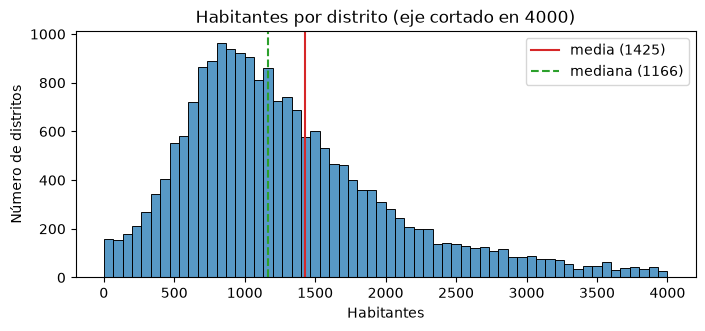

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.2))
sns.histplot(datos["Population"], bins=60, binrange=(0, 4000), ax=ax)
ax.axvline(datos["Population"].mean(), color="tab:red", label=f"media ({datos['Population'].mean():.0f})")
ax.axvline(datos["Population"].median(), color="tab:green", ls="--", label=f"mediana ({datos['Population'].median():.0f})")
ax.set_title("Habitantes por distrito (eje cortado en 4000)")
ax.set_xlabel("Habitantes")
ax.set_ylabel("Número de distritos")
ax.legend()
plt.show()

### 3.3. Dispersión

Para cada variable: desviación típica (con $n-1$), rango intercuartílico, MAD (con la escala que lo hace comparable a $\sigma$) y coeficiente de variación.

In [6]:
dispersion = pd.DataFrame({
    "desviación típica (n-1)": datos.std(),
    "RIC": datos.quantile(0.75) - datos.quantile(0.25),
    "MAD (escala normal)": datos.apply(lambda s: stats.median_abs_deviation(s, scale="normal")),
    "CV (desv./media)": datos.std() / datos.mean(),
})
dispersion.round(2)

,desviación típica (n-1),RIC,MAD (escala normal),CV (desv./media)
MedInc,1.90,2.18,1.58,0.49
HouseAge,12.59,19.00,14.83,0.44
Population,1132.46,938.00,652.34,0.79
AveRooms,2.47,1.61,1.19,0.46


En `Population` la desviación típica (1132) es mayor que el RIC (938) y que el MAD (652): las colas la inflan. Con datos normales, el RIC valdría $\approx 1{,}35\,\sigma$ y el MAD en escala normal coincidiría con $\sigma$; aquí `Population` queda lejos de eso, otra señal de que no es normal. El CV de `Population` (0,79) es el mayor: es la que más varía en términos relativos.

#### La corrección de Bessel
Tomamos como "población" los 20 640 valores de `MedInc` (así conocemos $\sigma^2$ de verdad), extraemos 20 000 muestras pequeñas con reemplazo y comparamos cuánto vale **de media** la varianza muestral calculada dividiendo por $n$ y por $n-1$.

In [7]:
poblacion = datos["MedInc"].to_numpy()
sigma2 = poblacion.var()                       # varianza poblacional (ddof=0): aquí SÍ tenemos toda la población
rng = np.random.default_rng(42)
filas = []
for n in [5, 30]:
    v_n, v_n1, s_n1 = [], [], []
    for _ in range(20000):
        m = rng.choice(poblacion, n)
        v_n.append(np.var(m, ddof=0)); v_n1.append(np.var(m, ddof=1)); s_n1.append(np.std(m, ddof=1))
    filas.append({"n": n, "varianza (÷n)": np.mean(v_n), "varianza (÷(n-1))": np.mean(v_n1), "σ² real": sigma2,
                  "desv. típica (÷(n-1))": np.mean(s_n1), "σ real": np.sqrt(sigma2)})
pd.DataFrame(filas).set_index("n").round(3)

,varianza (÷n),varianza (÷(n-1)),σ² real,desv. típica (÷(n-1)),σ real
n,,,,,
5,2.912,3.640,3.609,1.686,1.9
30,3.456,3.575,3.609,1.842,1.9


Con $n=5$, dividir por $n$ da de media **2,91** frente a la varianza real de **3,61**: subestima un 19 % (cerca del factor $(n-1)/n=0{,}8$); dividir por $n-1$ da **3,64**, que acierta salvo el error de la simulación. Con $n=30$ la diferencia se reduce (3,46 frente a 3,58) porque $(n-1)/n=0{,}97$. Observa que la **desviación típica** con $n-1$ sigue quedando por debajo de $\sigma$ (1,69 frente a 1,90 con $n=5$, y 1,84 con $n=30$): la raíz de un estimador insesgado no es insesgada.

La librería importa. `numpy.var` y `numpy.std` dividen por $n$ (`ddof=0`) por defecto; `pandas` (`Series.var`, `std`) y `scipy.stats.tvar` lo hacen por $n-1$:

In [8]:
print(f"np.var(x)           = {np.var(x):.4f}   (ddof=0, ÷n)")
print(f"np.var(x, ddof=1)   = {np.var(x, ddof=1):.4f}   (÷(n-1))")
print(f"pd.Series(x).var()  = {pd.Series(x).var():.4f}   (ddof=1 por defecto)")

np.var(x)           = 0.1758   (ddof=0, ÷n)
np.var(x, ddof=1)   = 0.1978   (÷(n-1))
pd.Series(x).var()  = 0.1978   (ddof=1 por defecto)


#### Diagrama de caja y regla del 1,5·RIC

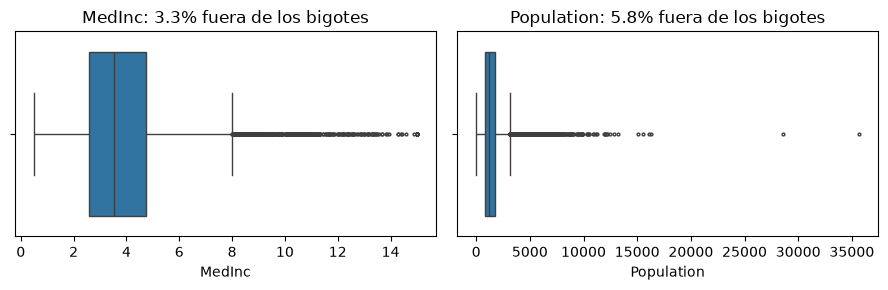

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, col in zip(axes, ["MedInc", "Population"]):
    sns.boxplot(x=datos[col], ax=ax, flierprops={"markersize": 2})
    q1, q3 = datos[col].quantile([0.25, 0.75])
    fuera = ((datos[col] < q1 - 1.5 * (q3 - q1)) | (datos[col] > q3 + 1.5 * (q3 - q1))).mean()
    ax.set_title(f"{col}: {fuera:.1%} fuera de los bigotes")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

La regla marca como "posibles atípicos" el 3,3 % de `MedInc` y el 5,8 % de `Population`. No son errores: en variables con cola larga a la derecha, esa regla (pensada para distribuciones simétricas) señala una parte normal de la cola. Marcar no es borrar; hay que mirar el caso (véase [limpieza de datos](../03-preparacion-datos/02-limpieza-datos.ipynb)).

#### Regla de Chebyshev
Comparamos la cota $1-1/k^2$ con la fracción real de datos a menos de $k$ desviaciones de la media.

In [10]:
filas = []
for col in ["MedInc", "Population"]:
    z = (datos[col] - datos[col].mean()) / datos[col].std()
    for k in [1.5, 2, 3]:
        filas.append({"variable": col, "k": k, "cota de Chebyshev (≥)": 1 - 1 / k ** 2, "fracción real": (z.abs() < k).mean(),
                      "si fuera normal": stats.norm.cdf(k) - stats.norm.cdf(-k)})
pd.DataFrame(filas).set_index(["variable", "k"]).round(3)

cota de Chebyshev (≥)  fracción real  si fuera normal
variable   k                                                         
MedInc     1.5                  0.556          0.923            0.866
           2.0                  0.750          0.959            0.954
           3.0                  0.889          0.983            0.997
Population 1.5                  0.556          0.942            0.866
           2.0                  0.750          0.963            0.954
           3.0                  0.889          0.983            0.997

La cota **se cumple** siempre (0,923 ≥ 0,556; 0,959 ≥ 0,75; 0,983 ≥ 0,889 en `MedInc`), pero es conservadora: la fracción real está más cerca de la columna "normal" que de la cota. Y a $k=3$ queda en 0,983 en las dos variables, por debajo de lo que daría una normal (0,997): las colas son más pesadas que las de una normal.

### 3.4. Forma: asimetría y curtosis

Calculamos los dos coeficientes de 2.4 y vemos qué hace el logaritmo con `Population`.

                 asimetría  curtosis en exceso
MedInc                1.65                4.95
HouseAge              0.06               -0.80
Population            4.94               73.54
AveRooms             20.70              879.14
log(Population)      -1.07                4.67


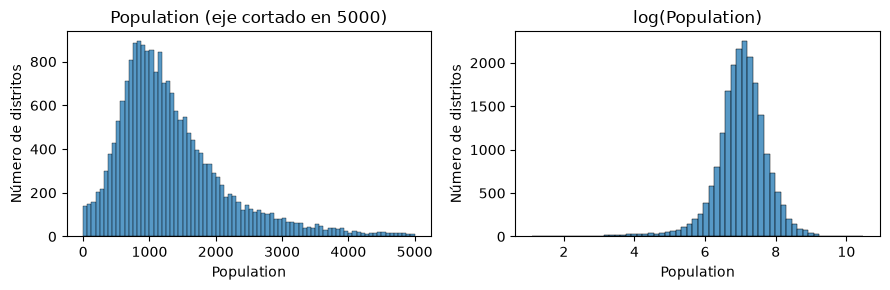

In [11]:
forma = pd.DataFrame({"asimetría": datos.apply(stats.skew), "curtosis en exceso": datos.apply(stats.kurtosis)})
log_pop = np.log(datos["Population"])
forma.loc["log(Population)"] = [stats.skew(log_pop), stats.kurtosis(log_pop)]
print(forma.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
sns.histplot(datos["Population"], bins=80, binrange=(0, 5000), ax=axes[0]); axes[0].set_title("Population (eje cortado en 5000)")
sns.histplot(log_pop, bins=60, ax=axes[1]); axes[1].set_title("log(Population)")
for ax in axes:
    ax.set_ylabel("Número de distritos")
plt.tight_layout()
plt.show()

`HouseAge` es simétrica (asimetría 0,06) y tiene curtosis negativa ($-0{,}8$: más "plana" que una normal, con las colas cortadas por el tope de 52). `MedInc` tiene asimetría positiva moderada (1,65) y `Population` **fuerte** (4,94) con una curtosis de 73,5: unas pocas observaciones extremas dominan el cuarto momento. `AveRooms` (asimetría 20,7 y curtosis 879) está dominada por un puñado de valores absurdos. El logaritmo de `Population` **corrige demasiado**: la asimetría pasa de 4,94 a $-1{,}07$ (la cola izquierda, de los distritos con muy pocos habitantes, se alarga) y la curtosis sigue siendo alta (4,7). El logaritmo no es una transformación mágica: se comprueba, no se aplica a ciegas.

### 3.5. Estandarización y cambios de unidad

In [12]:
z = pd.DataFrame({col: stats.zscore(datos[col], ddof=1) for col in ["MedInc", "HouseAge"]})
print("Tras estandarizar (media y desviación típica):")
print(z.agg(["mean", "std"]).round(3).to_string())

# Cambio de unidades: MedInc está en decenas de miles de dólares; a dólares es una transformación lineal y=a·x
dolares = datos["MedInc"] * 10_000
print(f"\nMedInc: media {datos['MedInc'].mean():.3f}, desv. típica {datos['MedInc'].std():.3f}")
print(f"En dólares (x10 000): media {dolares.mean():,.0f} = 10 000 · media; desv. típica {dolares.std():,.0f} = 10 000 · desv. típica")

# Atípicos con z clásico y con z robusto en Population
z_clasico = stats.zscore(datos["Population"], ddof=1)
mad = stats.median_abs_deviation(datos["Population"], scale="normal")
z_robusto = (datos["Population"] - datos["Population"].median()) / mad
print(f"\nPopulation con |z| > 3: clásico {(np.abs(z_clasico) > 3).sum()} distritos, robusto {(np.abs(z_robusto) > 3).sum()} distritos")

Tras estandarizar (media y desviación típica):
      MedInc  HouseAge
mean     0.0       0.0
std      1.0       1.0

MedInc: media 3.871, desv. típica 1.900
En dólares (x10 000): media 38,707 = 10 000 · media; desv. típica 18,998 = 10 000 · desv. típica

Population con |z| > 3: clásico 342 distritos, robusto 1209 distritos


Tras estandarizar, la media es 0 y la desviación típica 1 en las dos variables, aunque están en escalas muy distintas (dólares y años). Al pasar `MedInc` a dólares, la media y la desviación típica se multiplican por 10 000 (transformación lineal de 2.2 y 2.3), y el resultado no depende del cambio de unidad si trabajamos con $z$.

Con $|z|>3$, el $z$ clásico marca 342 distritos de `Population` y el robusto, **1 209**: el MAD (652) es mucho menor que la desviación típica (1132), así que el criterio robusto es más estricto y marca muchos más. Ninguno de los dos criterios dice que esos valores sean errores: en una variable con cola larga, "alejado de la mediana" es normal.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Función | Parámetro | Qué controla | Consejo |
|---|---|---|---|
| `numpy.var`, `numpy.std` | `ddof` | Divisor $n-\text{ddof}$ | **0 por defecto** (varianza poblacional); usa `ddof=1` para estimar con una muestra |
| `Series.var`, `Series.std` (pandas) | `ddof` | Igual | **1 por defecto**: los resultados de numpy y pandas no coinciden si no lo fijas |
| `scipy.stats.trim_mean` | `proportiontocut` | Fracción recortada en *cada* extremo | 0,05–0,2; con 0,5 se acerca a la mediana |
| `scipy.stats.skew`, `kurtosis` | `bias`, `fisher` | Corrección por muestra pequeña; curtosis en exceso (0 en la normal) o de Pearson (3) | `fisher=True` (por defecto) para comparar con la normal; fíjate en qué definición usa cada librería |
| `scipy.stats.median_abs_deviation` | `scale` | Escala del MAD | `"normal"` para compararlo con $\sigma$ |
| `Series.quantile` | `interpolation` | Cómo se interpola entre datos | Hay varias definiciones de cuartil y dan resultados algo distintos con pocos datos |
| `sns.boxplot` | `whis` | Longitud de los bigotes en RIC | 1,5 por defecto; es una convención, no una prueba estadística |

### 4.2. Errores comunes

- **Dar la media de una variable asimétrica como valor típico.** En `Population` la media (1425) supera a la mediana (1166) porque unos pocos distritos enormes la arrastran; con ingresos, precios o tiempos, informa la mediana (y los cuartiles).
- **Dividir por $n$ cuando es una muestra.** Subestima la varianza (3.3); con pocos datos el error es grande. Revisa qué `ddof` usa cada librería.
- **Creer que $s$ es insesgado.** $s^2$ lo es, $s$ no (queda algo por debajo de $\sigma$).
- **No ver datos recortados (censurados).** `HouseAge` tiene un 6,2 % de valores exactamente 52 (el tope). Con datos topados la media y la desviación subestiman la realidad, y el tope genera una moda falsa.
- **Tomar la regla del 1,5·RIC o $|z|>3$ como prueba de error.** Marcan valores extremos para un modelo simétrico; en una cola larga marcan decenas o miles de datos válidos (3.3, 3.5).
- **Usar el coeficiente de variación con media cercana a 0 o negativa**, o con variables sin un cero real (temperatura en °C): no tiene sentido.
- **Promediar promedios.** La media de las medias de varios grupos solo es la media global si los grupos tienen el mismo tamaño; hay que ponderar por $n$.
- **Confiar en los resúmenes sin mirar los datos.** Dos conjuntos distintos pueden tener los mismos resúmenes, como en la demo siguiente.

#### Demo: el cuarteto de Anscombe
Cuatro conjuntos de 11 pares $(x,y)$ con la **misma media, desviación típica y correlación**.

         media_x  desv_x  media_y  desv_y
dataset                                  
I            9.0    3.32      7.5    2.03
II           9.0    3.32      7.5    2.03
III          9.0    3.32      7.5    2.03
IV           9.0    3.32      7.5    2.03


Correlación: {'I': 0.816, 'II': 0.816, 'III': 0.816, 'IV': 0.817}


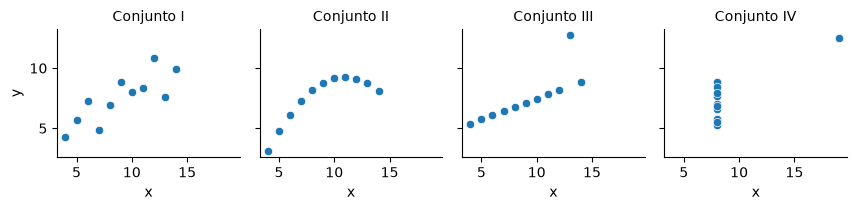

In [13]:
anscombe = sns.load_dataset("anscombe")
print(anscombe.groupby("dataset").agg(media_x=("x", "mean"), desv_x=("x", "std"), media_y=("y", "mean"), desv_y=("y", "std")).round(2).to_string())
print("Correlación:", anscombe.groupby("dataset").apply(lambda d: d["x"].corr(d["y"]), include_groups=False).round(3).to_dict())

g = sns.FacetGrid(anscombe, col="dataset", col_wrap=4, height=2.2)
g.map_dataframe(sns.scatterplot, x="x", y="y")
g.set_titles("Conjunto {col_name}")
plt.show()

Los cuatro conjuntos son idénticos para los resúmenes (media de $x$ = 9, de $y$ = 7,5, desviaciones 3,32 y 2,03, correlación 0,816) y completamente distintos en el gráfico: una relación lineal, una curva, una recta con un atípico y un punto que lo determina todo. **Los números resumen, no sustituyen mirar los datos.**

## 5. Comparación con métodos relacionados

| Aspecto | Media / desviación típica | Mediana / RIC (o MAD) |
|---|---|---|
| **Qué mide** | Centro y dispersión según las distancias al cuadrado | Centro y dispersión según posiciones (percentiles) |
| **Robustez a atípicos** | Baja: un valor la altera | Alta: hace falta alterar la mitad de los datos |
| **Con distribución simétrica y sin atípicos** | Más eficiente (usa toda la información), es la base de la inferencia clásica | Casi igual de buena, algo menos precisa |
| **Con cola larga** | Engaña (la media se aleja del "típico") | Representa mejor el valor típico |
| **Facilidad de cálculo y propiedades** | Fórmulas simples y propiedades algebraicas (suma de varianzas, transformaciones lineales) | Requiere ordenar; no se combina tan fácilmente entre grupos |
| **Cuándo usarla** | Datos aproximadamente simétricos; fundamentos de intervalos y contrastes | Datos asimétricos, con atípicos o con valores topados; resumen en un informe |

En la práctica se calculan **las dos** y se comparan: si la media y la mediana difieren mucho, la distribución es asimétrica o hay atípicos, y conviene entender por qué antes de elegir. Las [distribuciones de probabilidad](02-distribuciones-probabilidad.ipynb) dan los modelos teóricos (normal, etc.) con los que se interpretan $z$ y la regla empírica, y los resúmenes de este notebook son la base de la [inferencia](04-intervalos-confianza.ipynb).

## 6. Referencias

### Fuentes

- Pace, R. K. y Barry, R. (1997). *Sparse spatial autoregressions*. *Statistics & Probability Letters*, 33(3), 291–297. Origen de los datos de California housing, descargados con [`fetch_california_housing`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html).
- Anscombe, F. J. (1973). «Graphs in statistical analysis». *The American Statistician*, 27(1), 17–21. Origen del cuarteto de Anscombe, descargado con seaborn [`load_dataset("anscombe")`](https://seaborn.pydata.org/generated/seaborn.load_dataset.html).
- SciPy: [`scipy.stats`](https://docs.scipy.org/doc/scipy/reference/stats.html) (`trim_mean`, `skew`, `kurtosis`, `zscore`, `median_abs_deviation`).
- NumPy: [`numpy.var`](https://numpy.org/doc/stable/reference/generated/numpy.var.html). pandas: [`Series.var`](https://pandas.pydata.org/docs/reference/api/pandas.Series.var.html), [`DataFrame.describe`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html) y [`Series.quantile`](https://pandas.pydata.org/docs/reference/api/pandas.Series.quantile.html). seaborn: [`boxplot`](https://seaborn.pydata.org/generated/seaborn.boxplot.html).

### Para saber más

- Freedman, D., Pisani, R. y Purves, R. (2007). *Statistics* (4.ª ed.). W. W. Norton. Libro de introducción muy claro, con la intuición de media, desviación típica y gráficos antes de las fórmulas.
- Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley. Origen del resumen de cinco números y del diagrama de caja, y de la idea de resumir con medidas robustas.